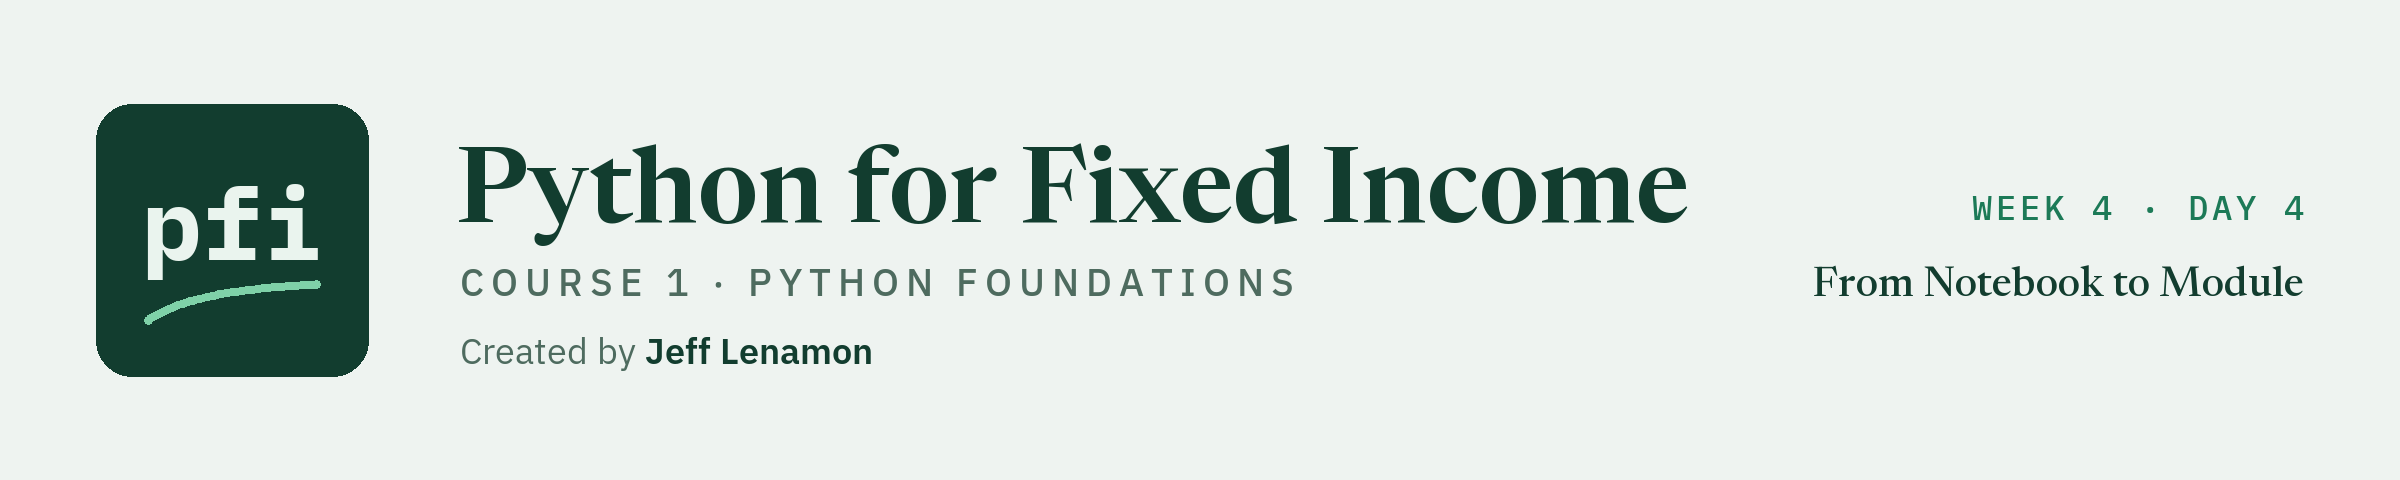

# From Notebook to Module

Week 4. The cleaning routine of week 3 is moved out of notebook cells into a file of functions, so that the same steps run on next month's extract by changing one file name.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course1_python_foundations/week4/day4/19_from_notebook_to_module.ipynb)

In week 3 you took the September extract, `holdings_messy.csv`, through a set of cleaning decisions and reconciled it to its cover note: **200 bonds, 489,000,000 dollars of face, and a market value of 490,819,215 dollars.** The work was done in notebook cells, one decision at a time, and that was the right place to do it. A notebook is where work is found.

Next month a new extract arrives. The decisions have not changed. Typing them again is slow, and it is also how a step gets left out. The desk wants the routine kept in one place, with its checks, so that anyone on the desk can run it on any month's file.

That place is a **module**: a plain text file ending in `.py` that holds functions. A notebook finds the work and a module keeps it. This notebook builds one, called `desk_tools.py`, and uses it.

1. Write the module from the notebook.
2. Import it, read its documentation, and call its functions.
3. Edit it, and reload it.
4. Run the same lines on two files and see what the checks say about each.
5. Write the result to an Excel workbook.
6. Test a function on a small table typed by hand.

Nearly everything here is something you have already met, put in a new place: functions with a docstring and a `return` (week 1, day 1), reading and writing files (week 1, day 2), checks that stop with `assert` and `raise ValueError` (week 1, day 3), Excel workbooks (week 2, day 3), and the cleaning decisions (week 3, day 3).

The issuers are invented. Every statement here describes the data, and nothing says a bond or a sector is good or bad.

## 19.1 Setting Up

Q. Import the libraries and check which versions are running.

In [1]:
# importlib reloads a module after it has been edited
import importlib
# os is used to find the data folder and to delete the files this notebook writes
import os
# sys holds settings of Python itself
import sys

import pandas as pd

# stop Python saving a compiled copy of the module in a __pycache__ folder,
# so that this folder ends the day holding only the files it started with
sys.dont_write_bytecode = True

print(f'pandas version: {pd.__version__}')
print(f'Python version: {sys.version_info.major}.{sys.version_info.minor}')

pandas version: 3.0.6
Python version: 3.13


* This notebook was saved with the versions printed above. Yours may differ, and in Google Colab they may be older.
* `importlib` and `sys` come with Python, like `os`. Nothing new needs installing.

Q. Find the data folder, and store the three control totals from the September cover note.

In [2]:
# on your own machine the files are in the repo's data folder. In Colab they are read from GitHub.
if os.path.exists('../../../data/holdings_messy.csv'):
    data_folder = '../../../data/'
else:
    data_folder = 'https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/'

# the control totals from the cover note
expected_bonds = 200
expected_face = 489_000_000
expected_value = 490_819_215

print(f'Expected bonds: {expected_bonds:,}')
print(f'Expected face: {expected_face:,} dollars')
print(f'Expected market value: {expected_value:,} dollars')

Expected bonds: 200
Expected face: 489,000,000 dollars
Expected market value: 490,819,215 dollars


* 200 bonds, 489,000,000 dollars of face, and 490,819,215 dollars of market value: the same control totals as week 3, day 3.
* Two files are used today. `holdings_messy.csv` is the September extract as the operations team sent it. `holdings.csv` is the same September book with no problems in it.

## 19.2 From Cells to a File

A function defined in a notebook cell lives in that notebook. Another notebook cannot call it, and a colleague cannot use it without copying the cell. Copies drift apart: one gets a fix and the other does not.

A module is one file that every notebook can import. `import pandas as pd` has been importing modules written by other people since week 2. Today the module is yours.

Q. Is there a file called `desk_tools.py` in this folder yet?

In [3]:
# os.path.exists() is True when the file is there
print(f"desk_tools.py exists: {os.path.exists('desk_tools.py')}")

desk_tools.py exists: False


* `False`. The file does not exist yet. The next cell writes it.

A `.py` file is plain text, and any editor can write one. In VS Code it would be File, New File. Here the notebook writes it, so that the same steps work on your machine and in Colab. A cell whose first line is `%%writefile desk_tools.py` is not run as Python. Jupyter saves everything below that line as the file named.

Read the cell before running it. It holds five functions, and every line of pandas in them was taught in an earlier notebook.

| Function | What it does |
| --- | --- |
| `load_holdings(path)` | reads the CSV and returns the table as it arrived |
| `clean_holdings(raw)` | applies the cleaning decisions of week 3, day 3, and returns the cleaned table |
| `check_totals(book, bonds, face, market_value)` | tests a table against the cover note, and raises an error if it does not match |
| `summarize(book)` | returns the headline numbers as a table with one row |
| `write_report(book, summary, path)` | writes the book and the headline table to an Excel workbook |

Q. Write the module.

In [4]:
%%writefile desk_tools.py
"""Desk tools: load, clean, check, summarize, and report a month-end holdings extract.

Written in notebook 19 of Python for Fixed Income. All portfolio data is synthetic.
"""
import pandas as pd


def load_holdings(path: str) -> pd.DataFrame:
    """Read a holdings extract from a CSV file and return it as it arrived.

    path is the file name or the web address of the CSV. The CUSIP is read as text.
    """
    return pd.read_csv(path, dtype={'cusip': str})


def clean_holdings(raw):
    """Apply the desk's cleaning decisions to an extract and return the cleaned table.

    The six decisions of week 3, day 3, in the same order:
      1. Exact duplicate rows are removed, keeping the first of each.
      2. Tickers are tidied: no spaces at either end, all capitals.
      3. A price dated on another day than the as-of date is flagged in a new column,
         stale_price. The price is not changed.
      4. A missing rating is labelled 'Not rated'. The bond stays in the book.
      5. A yield entered as a decimal is multiplied by 100. The test is the IQR rule:
         a yield below the first quartile less 1.5 times the IQR.
      6. Bonds with very wide spreads are real, and they are kept.

    raw is not changed. The cleaned table has one more column than raw: stale_price.
    """
    # work in a copy, so that the table passed in stays as it arrived
    book = raw.copy()

    # decision 1: remove the repeated rows and renumber the rows from 0
    book = book.drop_duplicates().reset_index(drop=True)

    # decision 2: tidy the tickers
    book['ticker'] = book['ticker'].str.strip().str.upper()

    # decision 3: flag the stale prices, and leave them as they are
    book['stale_price'] = book['price_date'] != book['as_of_date']

    # decision 4: label the missing ratings
    book['rating'] = book['rating'].fillna('Not rated')

    # decision 5: yields in percent, where one was entered as a decimal
    q1 = book['yield_pct'].quantile(0.25)
    q3 = book['yield_pct'].quantile(0.75)
    lower_limit = q1 - 1.5 * (q3 - q1)
    entered_as_decimal = book['yield_pct'] < lower_limit
    book.loc[entered_as_decimal, 'yield_pct'] = (book.loc[entered_as_decimal, 'yield_pct'] * 100).round(3)

    # decision 6: the very wide bonds are real and they stay, so there is no line for them

    return book


def check_totals(book, bonds, face, market_value):
    """Test a table against its three control totals. Raise ValueError if any one does not match.

    bonds is the number of rows the table should have. face and market_value are in dollars.
    Nothing is returned: if the function finishes without an error, the table matches.
    """
    found_bonds = len(book)
    found_face = book['par_held'].sum()
    found_value = book['market_value'].sum()

    # collect every mismatch, so that one message reports them all
    problems = []
    if found_bonds != bonds:
        problems.append(f'{found_bonds:,} rows against {bonds:,} bonds')
    if found_face != face:
        problems.append(f'face of {found_face:,} against {face:,} dollars')
    # market value has cents, so allow half a cent for decimal arithmetic
    if abs(found_value - market_value) > 0.005:
        problems.append(f'market value of {found_value:,.2f} against {market_value:,.2f} dollars')

    if problems:
        raise ValueError('control totals do not match: ' + '; '.join(problems))


def summarize(book):
    """Return the headline table of a cleaned book: one row, one column for each figure.

    face and market_value are in dollars, mean_oas in basis points, mean_yield in percent.
    not_rated and stale_prices count the bonds that clean_holdings labelled or flagged.
    """
    headline = {
        'bonds': len(book),
        'face': book['par_held'].sum(),
        'market_value': book['market_value'].sum(),
        'mean_oas': round(book['oas'].mean(), 2),
        'mean_yield': round(book['yield_pct'].mean(), 3),
        'not_rated': (book['rating'] == 'Not rated').sum(),
        'stale_prices': book['stale_price'].sum(),
    }
    # a list holding one dictionary becomes a table with one row
    return pd.DataFrame([headline])


def write_report(book, summary, path):
    """Write the month-end workbook to path: the headline table on a sheet named 'summary'
    and the cleaned book on a sheet named 'book'.
    """
    with pd.ExcelWriter(path) as writer:
        summary.to_excel(writer, sheet_name='summary', index=False)
        book.to_excel(writer, sheet_name='book', index=False)

Writing desk_tools.py


* `Writing desk_tools.py` is the whole output. Nothing in the cell ran. The functions do not exist in this notebook yet: there is only a text file.
* The file opens with a docstring for the module, then its own `import pandas as pd`. A module does not see the notebook's imports or the notebook's variables. Everything a function needs comes in through its parameters, and everything it produces goes out through `return`. That is why `clean_holdings` takes `raw` and returns `book`, and never reaches for a table that happens to exist in a notebook.
* Each function opens with a docstring that says what goes in, what comes out, and the units.
* `clean_holdings` makes the six decisions of week 3, day 3, in the same order. Two are written down differently, both so that the function needs nothing but the extract. A missing rating is labelled in the `rating` column itself, where week 3 labelled the bucket and the grade from the rating scale. And a stale price is flagged in a column of its own, `stale_price`, where week 3 kept a separate list.

Q. Is the file there now, and how long is it?

In [5]:
# read the file back as lines of text, as in week 1, day 2
with open('desk_tools.py') as file:
    lines = file.readlines()

# a function definition starts with def at the left edge of the line
definitions = [line for line in lines if line.startswith('def ')]

print(f"desk_tools.py exists: {os.path.exists('desk_tools.py')}")
print(f'Lines in the file: {len(lines)}')
print(f'Functions defined: {len(definitions)}')

desk_tools.py exists: True
Lines in the file: 107
Functions defined: 5


* The file exists, it has 107 lines, and it defines 5 functions.
* Open it in VS Code from the file explorer on the left. It is ordinary Python with no cells and no outputs.

**Excel side by side.** The nearest everyday comparison is a workbook of calculations that other workbooks refer to: the logic is kept in one file and used from many. The comparison is loose. A module holds steps and no data, so the same module is used on every month's file.

## 19.3 Importing the Module

`import` finds the file, runs it from top to bottom once, and gives the notebook a name through which every function in the file can be reached. Python looks for the file in the notebook's own folder first, which is where the cell above wrote it.

Q. Import the module and list what it holds.

In [6]:
# the name after import is the file name without .py
import desk_tools

# dir() lists the names inside the module. Names that start with an underscore are Python's own.
names = [name for name in dir(desk_tools) if not name.startswith('_')]
print(names)

['check_totals', 'clean_holdings', 'load_holdings', 'pd', 'summarize', 'write_report']


* The five functions, in alphabetical order, and `pd`, the module's own import of pandas.
* A function in the module is called with the module's name in front: `desk_tools.load_holdings(...)`. This is the same dot as in `pd.read_csv(...)`.

Q. What does `clean_holdings` do? Ask the module.

In [7]:
# help() prints the signature of a function and its docstring
help(desk_tools.clean_holdings)

Help on function clean_holdings in module desk_tools:

clean_holdings(raw)
    Apply the desk's cleaning decisions to an extract and return the cleaned table.

    The six decisions of week 3, day 3, in the same order:
      1. Exact duplicate rows are removed, keeping the first of each.
      2. Tickers are tidied: no spaces at either end, all capitals.
      3. A price dated on another day than the as-of date is flagged in a new column,
         stale_price. The price is not changed.
      4. A missing rating is labelled 'Not rated'. The bond stays in the book.
      5. A yield entered as a decimal is multiplied by 100. The test is the IQR rule:
         a yield below the first quartile less 1.5 times the IQR.
      6. Bonds with very wide spreads are real, and they are kept.

    raw is not changed. The cleaned table has one more column than raw: stale_price.



* The first line of the output is the signature: the name and its one parameter, `raw`. The rest is the docstring, word for word as it was typed in the file.
* A docstring is the documentation. The person who uses the function next month reads this, and never has to read the code. That person is often you.
* `help(pd.read_csv)` works the same way, on a much longer docstring.

Q. One function in the module has more in its signature than the others. What does the extra part say?

In [8]:
help(desk_tools.load_holdings)

# the same information as a dictionary
print(desk_tools.load_holdings.__annotations__)

Help on function load_holdings in module desk_tools:

load_holdings(path: str) -> pandas.DataFrame
    Read a holdings extract from a CSV file and return it as it arrived.

    path is the file name or the web address of the CSV. The CUSIP is read as text.

{'path': <class 'str'>, 'return': <class 'pandas.DataFrame'>}


* The signature reads `load_holdings(path: str) -> pandas.DataFrame`. The parts after the colon and after the arrow are **type hints**.
* `path: str` says the function expects `path` to be text. `-> pd.DataFrame` says the function returns a DataFrame.
* Hints are notes for the reader and for the editor. Python does not enforce them: a wrong type is not stopped by the hint. VS Code uses them to suggest what can follow a dot.
* This course does not ask you to write type hints. You will meet them in other people's code and in code an AI assistant writes, so it is enough to read them: the name, a colon, the type that goes in, and after the arrow the type that comes out.

## 19.4 Running the Month End

The module is used the way pandas is: call a function, keep what it returns.

Q. Load the September extract with the module.

In [9]:
# raw is the file exactly as it arrived
raw = desk_tools.load_holdings(data_folder + 'holdings_messy.csv')

print(f'Rows: {len(raw):,}  columns: {raw.shape[1]}')
print(f"Face: {raw['par_held'].sum():,} dollars")
print(f"Market value: {raw['market_value'].sum():,.2f} dollars")

Rows: 204  columns: 19
Face: 495,500,000 dollars
Market value: 497,769,925.00 dollars


* 204 rows and 19 columns, 495,500,000 dollars of face, and 497,769,925.00 dollars of market value. These are the figures week 3 started from.

**Predict 1**

```
desk_tools.check_totals(raw, expected_bonds, expected_face, expected_value)
```

The extract has not been cleaned, and it has 204 rows where the cover note says 200. What does this line do?

> A) it prints the three differences and the notebook carries on
>
> B) it returns `False`
>
> C) it raises an error, and the cell stops

Decide, then run the cell.

In [10]:
# the raw extract against the cover note
desk_tools.check_totals(raw, expected_bonds, expected_face, expected_value)

ValueError: control totals do not match: 204 rows against 200 bonds; face of 495,500,000 against 489,000,000 dollars; market value of 497,769,925.00 against 490,819,215.00 dollars

* C. A `ValueError`, and the last line carries the message the function built: `control totals do not match: 204 rows against 200 bonds; face of 495,500,000 against 489,000,000 dollars; market value of 497,769,925.00 against 490,819,215.00 dollars`.
* The traceback has two parts. The first arrow points at the line in this notebook that made the call. The second points at the `raise` line inside `desk_tools.py`. Read from the bottom: the message first, then where it was raised, then who called it.
* This is the check that stops, from week 1, day 3. A printed difference can be scrolled past. An error cannot: in a full run, nothing below this cell would execute, so no report could be written from a table that does not match its cover note.
* This cell is tagged so that the rest of the notebook runs. Without the tag, Run All would stop here, and that is the behaviour a desk wants.

Q. Clean the extract.

In [11]:
# clean_holdings returns a new table. raw is passed in and is not changed.
book = desk_tools.clean_holdings(raw)

print(f'Rows in raw: {len(raw):,}  rows in book: {len(book):,}')
print(f'Columns in raw: {raw.shape[1]}  columns in book: {book.shape[1]}')
print(f"Market value of book: {book['market_value'].sum():,.2f} dollars")

Rows in raw: 204  rows in book: 200
Columns in raw: 19  columns in book: 20
Market value of book: 490,819,215.00 dollars


* 204 rows went in and 200 came out, with a market value of 490,819,215.00 dollars. The cleaned table has 20 columns: the 19 of the extract and `stale_price`.
* One line did what took a section of the week 3 notebook, because the decisions were made then. A function does not decide anything. It repeats decisions that someone made, looking at the data, and wrote down.

Q. Does the cleaned table match the cover note?

In [12]:
# the same call as before, on the cleaned table
desk_tools.check_totals(book, expected_bonds, expected_face, expected_value)

# this line is reached only if the check did not raise
print(f'Control totals match: {len(book):,} bonds, {book["par_held"].sum():,} dollars of face, '
      f'{book["market_value"].sum():,.2f} dollars of market value')

Control totals match: 200 bonds, 489,000,000 dollars of face, 490,819,215.00 dollars of market value


* No error, so the second line ran: 200 bonds, 489,000,000 dollars of face, and 490,819,215.00 dollars of market value.
* A check that passes says nothing. That is by design: silence means the table matches, and the `print` after it is there for the reader.

Q. Did cleaning change the extract that was passed in?

In [13]:
# the same tests on raw as in week 3: repeated rows, untidy tickers, missing ratings
untidy = raw['ticker'] != raw['ticker'].str.strip().str.upper()

print(f'Rows in raw: {len(raw):,}')
print(f'Repeated rows in raw: {raw.duplicated().sum()}')
print(f'Untidy tickers in raw: {untidy.sum()}')
print(f"Missing ratings in raw: {raw['rating'].isna().sum()}")

Rows in raw: 204
Repeated rows in raw: 4
Untidy tickers in raw: 8
Missing ratings in raw: 5


* `raw` still has 204 rows, 4 repeated rows, 8 untidy tickers, and 5 missing ratings. The function worked in a copy, as its docstring says, and the file as received is still there to go back to.

Q. What are the headline numbers of the cleaned book?

In [14]:
# summarize returns a table with one row
summary = desk_tools.summarize(book)
summary

,bonds,face,market_value,mean_oas,mean_yield,not_rated,stale_prices
0,200,489000000,490819215.0,185.75,6.088,5,6


* 200 bonds, 489,000,000 dollars of face, 490,819,215 dollars of market value, a mean OAS of 185.75 basis points, and a mean yield of 6.088 percent: the figures week 3 reported for the month-end pack.
* The last two columns carry what could not be fixed: 5 bonds are labelled Not rated and 6 prices are flagged as stale. They are open items for the operations team, and the summary keeps them in view.

**Excel side by side.** On a sheet holding the cleaned book, the three control totals are `=COUNTA(B2:B201)`, `=SUM(R2:R201)`, and `=SUM(S2:S201)`, with the CUSIP in column B, the face in column R, and the market value in column S. A formula such as `=IF(COUNTA(B2:B201)=200, "OK", "CHECK")` shows the result of a check in its cell, and the reader has to look at the cell. `check_totals` stops the run.

## 19.5 Editing the Module and Reloading

The summary says what the book looks like after cleaning. It does not say what cleaning did. The desk wants a count for each decision: how many rows were removed, how many tickers tidied, and so on. That is a sixth function, `count_changes(raw, book)`.

`%%writefile -a` adds to the end of a file where `%%writefile` replaces it. The `-a` stands for append, the same idea as opening a file with `'a'` in week 1, day 2.

Q. Add `count_changes` to the module.

In [15]:
%%writefile -a desk_tools.py


def count_changes(raw, book):
    """Count what clean_holdings changed: one row, one column for each decision.

    raw is the extract as it arrived and book is the table clean_holdings returned for it.
    """
    # the extract with its repeated rows removed lines up row for row with the cleaned book
    kept = raw.drop_duplicates().reset_index(drop=True)
    counts = {
        'rows_removed': len(raw) - len(book),
        'tickers_tidied': (kept['ticker'] != book['ticker']).sum(),
        'stale_prices_flagged': book['stale_price'].sum(),
        'ratings_labelled': kept['rating'].isna().sum(),
        'yields_corrected': (kept['yield_pct'] != book['yield_pct']).sum(),
    }
    return pd.DataFrame([counts])

Appending to desk_tools.py


* `Appending to desk_tools.py`. The file on disk now holds six functions.

**Predict 2**

```
changes = desk_tools.count_changes(raw, book)
```

The file was changed a moment ago and the function is in it. The notebook imported `desk_tools` in section 19.3. What does this line do?

> A) it works: Python reads the file again each time a function is called
>
> B) it raises an error: the notebook is still using the module as it was when it was imported

Decide, then run the cell.

In [16]:
changes = desk_tools.count_changes(raw, book)

AttributeError: module 'desk_tools' has no attribute 'count_changes'

* B. An `AttributeError`: `module 'desk_tools' has no attribute 'count_changes'`.
* `import` ran the file once, in section 19.3, and the notebook has been using that copy ever since. Changing the file on disk does not change the copy in memory. This is the notebook rule from week 1 again: what counts is what has been run, not what is written.
* Running `import desk_tools` a second time does not help. Python sees that the module is already imported and does nothing.

Q. Reload the module, and count the changes.

In [17]:
# reload() runs the file again from top to bottom and replaces the copy in memory
importlib.reload(desk_tools)

# one count for each decision
changes = desk_tools.count_changes(raw, book)
changes

,rows_removed,tickers_tidied,stale_prices_flagged,ratings_labelled,yields_corrected
0,4,8,6,5,2


* After the reload the function is there. On the September extract: 4 rows removed, 8 tickers tidied, 6 stale prices flagged, 5 ratings labelled, and 2 yields corrected. These are the counts week 3 found one section at a time, in the order of its decision log.
* The habit: after every edit to a `.py` file, reload it, or restart the kernel and run from the top. A restart is the surer of the two, and it is what Restart and Run All does.
* In VS Code you would edit `desk_tools.py` in the editor and save it. The reload step is the same.

## 19.6 The Same Lines on a Second File

This is what the module is for. The lines that ran on one file run on another by changing the file name.

The second file is `holdings.csv`: the same September book, with the same cover note, sent without problems. A routine that is safe to keep must do two things. It must fix the file that has problems, and it must leave alone the file that has none.

Q. Does each file, as received, match the cover note?

In [18]:
files = ['holdings_messy.csv', 'holdings.csv']

for file in files:
    received = desk_tools.load_holdings(data_folder + file)
    # try and except, from week 1, day 3: catch the error, report it, and go on to the next file
    try:
        desk_tools.check_totals(received, expected_bonds, expected_face, expected_value)
        print(f'{file}: matches the cover note as received')
    except ValueError as error:
        print(f'{file}: {error}')

holdings_messy.csv: control totals do not match: 204 rows against 200 bonds; face of 495,500,000 against 489,000,000 dollars; market value of 497,769,925.00 against 490,819,215.00 dollars
holdings.csv: matches the cover note as received


* `holdings_messy.csv` fails as received, with the message seen above: 204 rows against 200 bonds, and both dollar totals too high.
* `holdings.csv` matches the cover note before anything is done to it.
* `except ValueError as error` catches the error that `check_totals` raises and stores it in `error`, and printing it shows the message. Catching is right here because the purpose of the cell is to report on both files. In the run below nothing is caught: if a cleaned table does not match, the run should stop.

**Predict 3**

The next cell runs `clean_holdings` and `count_changes` on both files. For `holdings.csv`, the file with no problems, what will the five counts be?

> A) all zero
>
> B) zero rows removed, and a few yields corrected, because the IQR rule always flags something
>
> C) the same as for the messy file, because it is the same book

Decide, then run the cell.

In [19]:
# the results of each file are kept in dictionaries, with the file name as the key
books = {}
summaries = {}
changes = {}

for file in files:
    # the same five lines for every file
    raw_file = desk_tools.load_holdings(data_folder + file)
    book_file = desk_tools.clean_holdings(raw_file)
    desk_tools.check_totals(book_file, expected_bonds, expected_face, expected_value)
    summaries[file] = desk_tools.summarize(book_file)
    changes[file] = desk_tools.count_changes(raw_file, book_file)

    books[file] = book_file
    print(f'{file}: {len(raw_file):,} rows in, {len(book_file):,} rows out, control totals match')

# concat() stacks the one-row tables, and the dictionary keys become the row labels
all_changes = pd.concat(changes).droplevel(1)
all_changes

holdings_messy.csv: 204 rows in, 200 rows out, control totals match
holdings.csv: 200 rows in, 200 rows out, control totals match


,rows_removed,tickers_tidied,stale_prices_flagged,ratings_labelled,yields_corrected
holdings_messy.csv,4,8,6,5,2
holdings.csv,0,0,0,0,0


* A. For `holdings.csv` every count is 0: no rows removed, no tickers tidied, no stale prices flagged, no ratings labelled, no yields corrected. 200 rows went in and 200 came out.
* For `holdings_messy.csv` the counts are 4, 8, 6, 5, and 2, as before, and 204 rows became 200.
* `check_totals` raised nothing for either file, so both cleaned tables match the cover note.
* The IQR rule did not flag a yield in the clean file. Its lower limit there is 3.055 percent and the lowest yield in the file is 4.089 percent. A rule that flagged a real yield would have multiplied it by 100, which is why the count of zero on a clean file is worth seeing and not assuming.

Q. How do the headline numbers of the two cleaned books compare?

In [20]:
all_summaries = pd.concat(summaries).droplevel(1)
all_summaries

,bonds,face,market_value,mean_oas,mean_yield,not_rated,stale_prices
holdings_messy.csv,200,489000000,490819215.0,185.75,6.088,5,6
holdings.csv,200,489000000,490819215.0,185.75,6.088,0,0


* The first five columns are the same in both rows: 200 bonds, 489,000,000 dollars of face, 490,819,215 dollars of market value, a mean OAS of 185.75 basis points, and a mean yield of 6.088 percent.
* The last two differ. The cleaned messy file has 5 bonds labelled Not rated and 6 stale prices. The clean file has 0 of each. Cleaning corrected what the file gave evidence for, and what it could not correct it labelled and counted.

Q. In which columns do the two cleaned books differ, and in how many rows?

In [21]:
from_messy = books['holdings_messy.csv']
from_clean = books['holdings.csv']

print(f"Same CUSIPs in the same order: {(from_messy['cusip'] == from_clean['cusip']).all()}")

# for each column, count the rows where the two tables hold different values
for column in from_messy.columns:
    different = (from_messy[column] != from_clean[column]).sum()
    if different > 0:
        print(f'{column}: {different} rows differ')

Same CUSIPs in the same order: True
rating: 5 rows differ
price_date: 6 rows differ
stale_price: 6 rows differ


* The same 200 CUSIPs in the same order. Of the 20 columns, 17 are identical in every row, including the ticker, where 8 values were tidied, and the yield, where 2 were corrected.
* Three columns differ: `rating` in 5 rows, `price_date` in 6, and `stale_price` in the same 6. Those are the ratings and prices that the operations team has to supply. This is the reconciliation of week 3, day 3, reached again with five lines.

**Excel side by side.** A workbook built for September is run on a new extract by pasting the new rows over the old ones, or by pointing the formulas at the new sheet, and then checking that every range still covers every row: the messy extract has 204 rows of data and the clean one has 200, so a range written as `S2:S205` for one is `S2:S201` for the other. In the loop above the only thing that changed between the two runs was the file name.

## 19.7 The Report Workbook

The portfolio manager reads Excel. The last function in the module writes the cleaned book and its headline table to one workbook with two sheets, using `pd.ExcelWriter` from week 2, day 3.

Q. Write the report for the September extract.

In [22]:
report_file = 'month_end_report.xlsx'

# the cleaned book and the headline table of the messy extract
book = books['holdings_messy.csv']
summary = summaries['holdings_messy.csv']

desk_tools.write_report(book, summary, report_file)

print(f'{report_file} exists: {os.path.exists(report_file)}')
print(f'Size: {os.path.getsize(report_file):,} bytes')

month_end_report.xlsx exists: True
Size: 29,297 bytes


* The workbook is in this folder, beside the notebook. Open it in Excel if you are working on your own machine: a `summary` sheet with one row of figures, and a `book` sheet with 200 rows.

Q. Read both sheets back and confirm what was written.

In [23]:
# sheet_name= picks the sheet. dtype= keeps the CUSIP as text, as in week 2, day 3.
summary_back = pd.read_excel(report_file, sheet_name='summary')
book_back = pd.read_excel(report_file, sheet_name='book', dtype={'cusip': str})

print(f'summary sheet: {summary_back.shape[0]} row, {summary_back.shape[1]} columns')
print(f'book sheet: {book_back.shape[0]:,} rows, {book_back.shape[1]} columns')

# the sheet read back must still match the cover note
desk_tools.check_totals(book_back, expected_bonds, expected_face, expected_value)
print('The book sheet matches the cover note')

summary_back

summary sheet: 1 row, 7 columns
book sheet: 200 rows, 20 columns
The book sheet matches the cover note


,bonds,face,market_value,mean_oas,mean_yield,not_rated,stale_prices
0,200,489000000,490819215,185.75,6.088,5,6


* The `summary` sheet has 1 row and 7 columns, and the `book` sheet has 200 rows and 20 columns. The headline figures are the ones written.
* `check_totals` ran on the table read back from Excel and raised nothing. The function does not care where a table came from: a CSV, a workbook, or a table typed in a cell.
* The workbook holds values. The cells of the `summary` sheet are numbers that pandas wrote, not formulas, so they do not change if someone edits the `book` sheet.

| Job | pandas | Excel |
| --- | --- | --- |
| Two tables in one file | `pd.ExcelWriter(path)` and `to_excel(writer, sheet_name=...)` once for each table | one workbook, two sheets |
| Read one sheet | `pd.read_excel(path, sheet_name='summary')` | open the workbook and select the `summary` tab |
| Control totals of the sheet | `desk_tools.check_totals(book_back, 200, 489_000_000, 490_819_215)` | `=COUNTA(book!B2:B201)`, `=SUM(book!R2:R201)`, `=SUM(book!S2:S201)` |

Q. Delete the workbook, so that the folder is left as it was.

In [24]:
# os.remove() deletes a file
os.remove(report_file)

print(f'{report_file} exists: {os.path.exists(report_file)}')

month_end_report.xlsx exists: False


* `False`. The report is gone. On a desk the workbook would be kept and sent. In the course, every file a notebook writes is removed by the notebook.

## 19.8 Testing a Function

The control totals test the result of a run. A **test** checks the function itself, on a table small enough to work out by hand. If someone edits `clean_holdings` next year and breaks the ticker step, the control totals will still match, because tickers are in no total. A test that looks at tickers will fail.

The method: type a tiny table with one of each problem, work out what the function should return, and `assert` that it does.

Q. Type a table of seven rows that holds a repeated row, an untidy ticker, a missing rating, a yield entered as a decimal, and a stale price.

In [25]:
# seven rows. The CUSIPs and the figures are made up for the test.
tiny = pd.DataFrame({
    'cusip': ['TEST00001', 'TEST00002', 'TEST00003', 'TEST00004', 'TEST00005', 'TEST00006', 'TEST00006'],
    'ticker': ['KRIX', ' krix', 'MORX', 'MORX', 'THAA', 'CORA', 'CORA'],
    'rating': ['BBB', 'BBB', None, 'A', 'BB', 'B', 'B'],
    'yield_pct': [5.1, 6.2, 5.5, 4.9, 0.0575, 5.8, 5.8],
    'as_of_date': ['2026-09-30'] * 7,
    'price_date': ['2026-09-30', '2026-09-30', '2026-09-30', '2026-08-14', '2026-09-30', '2026-09-30', '2026-09-30'],
})

tiny

,cusip,ticker,rating,yield_pct,as_of_date,price_date
0,TEST00001,KRIX,BBB,5.1000,2026-09-30,2026-09-30
1,TEST00002,krix,BBB,6.2000,2026-09-30,2026-09-30
2,TEST00003,MORX,NaN,5.5000,2026-09-30,2026-09-30
3,TEST00004,MORX,A,4.9000,2026-09-30,2026-08-14
4,TEST00005,THAA,BB,0.0575,2026-09-30,2026-09-30
5,TEST00006,CORA,B,5.8000,2026-09-30,2026-09-30
6,TEST00006,CORA,B,5.8000,2026-09-30,2026-09-30


* Row 6 is an exact copy of row 5. Row 1 has the ticker ` krix`, with a space and in lower case. Row 2 has no rating. Row 4 has a yield of 0.0575 where 5.75 percent was meant. Row 3 has a price dated in August.
* The table has only the six columns that `clean_holdings` reads. A function can be tested on far less than a full extract.
* The expected result, worked out by hand: 6 rows, the tickers `KRIX, KRIX, MORX, MORX, THAA, CORA`, the rating of row 2 labelled `Not rated`, a yield of 5.75 in row 4, and one stale price, in row 3.

Q. Clean the tiny table, and test that the repeated row was removed.

In [26]:
tidy = desk_tools.clean_holdings(tiny)

# an assert that passes prints nothing, so say what was tested
assert len(tidy) == 6, f'expected 6 rows, found {len(tidy)}'
assert tidy['cusip'].is_unique, 'a CUSIP is still repeated'
assert len(tiny) == 7, 'the table passed in was changed'

print(f'Test 1 passed: {len(tiny)} rows in, {len(tidy)} rows out, every CUSIP once')

Test 1 passed: 7 rows in, 6 rows out, every CUSIP once


* 7 rows in and 6 out. All three asserts passed, so the `print` was reached.
* The third assert tests the promise in the docstring: the table passed in is not changed.

Q. Test the tickers, and test the yield.

In [27]:
# the tickers, in row order, against the list worked out by hand
expected_tickers = ['KRIX', 'KRIX', 'MORX', 'MORX', 'THAA', 'CORA']
assert tidy['ticker'].tolist() == expected_tickers, f"tickers are {tidy['ticker'].tolist()}"
print(f"Test 2 passed: tickers are {tidy['ticker'].tolist()}")

# the yield entered as a decimal, and the five that should not have moved
assert tidy.loc[4, 'yield_pct'] == 5.75, f"yield in row 4 is {tidy.loc[4, 'yield_pct']}"
assert tidy['yield_pct'].tolist() == [5.1, 6.2, 5.5, 4.9, 5.75, 5.8], 'another yield was changed'
print(f"Test 3 passed: yields are {tidy['yield_pct'].tolist()}")

Test 2 passed: tickers are ['KRIX', 'KRIX', 'MORX', 'MORX', 'THAA', 'CORA']
Test 3 passed: yields are [5.1, 6.2, 5.5, 4.9, 5.75, 5.8]


* ` krix` became `KRIX`, and 0.0575 became 5.75. The other five yields are as typed.
* The test of the yields has two halves, and the second matters as much as the first: the function must correct the wrong value and must not touch the right ones.
* The IQR rule needs a few rows to work with, which is why the tiny table has six bonds and not two.

Now a test that fails. A colleague remembers the label for a missing rating as `NR` and writes the test that way.

Q. What does a failing test look like?

In [28]:
# the label the colleague expects
assert tidy.loc[2, 'rating'] == 'NR', f"expected the label NR, found {tidy.loc[2, 'rating']}"
print('Test 4 passed')

AssertionError: expected the label NR, found Not rated

* An `AssertionError`, with the message `expected the label NR, found Not rated`. The `print` under it did not run.
* A failing test says that the function and the test disagree. It does not say which is wrong. Here the docstring settles it: decision 4 says the label is `Not rated`, so the test is wrong and the function is right. On another day it is the function.
* The message was written to carry the value found. An assert with no message would say only that something was false.

Q. Put the tests that pass into one function, so that they can all be run again with one line.

In [29]:
def test_clean_holdings():
    # the five checks, on the tiny table typed above
    result = desk_tools.clean_holdings(tiny)

    assert len(result) == 6, f'expected 6 rows, found {len(result)}'
    assert result['ticker'].tolist() == ['KRIX', 'KRIX', 'MORX', 'MORX', 'THAA', 'CORA'], 'tickers not tidied'
    assert result.loc[2, 'rating'] == 'Not rated', 'missing rating not labelled'
    assert result['yield_pct'].tolist() == [5.1, 6.2, 5.5, 4.9, 5.75, 5.8], 'yields not as expected'
    assert result['stale_price'].tolist() == [False, False, False, True, False, False], 'stale price not flagged'

    print('clean_holdings: 5 checks passed')


test_clean_holdings()

clean_holdings: 5 checks passed


* `clean_holdings: 5 checks passed`. One line now tests every decision in the function.
* Run it after every edit to `clean_holdings`, straight after the reload. If an edit breaks a decision, the assert for that decision stops the run and names it.
* A tool called `pytest` finds every function whose name starts with `test_` and runs them all with one command. Later courses in this series use it. The tests it runs are written exactly like this one.

**Excel side by side.** The same idea in a workbook is a small sheet of made-up rows with known answers, kept beside the real data, on which a formula is tried before it is trusted on 200 rows.

## 19.9 A Module That Is Also a Program

Sooner or later you will open someone else's `.py` file and find this line near the bottom:

```
if __name__ == '__main__':
```

Python gives every file a variable called `__name__`. When the file is imported, `__name__` is the module's name. When the file is run directly as a program, `__name__` is the text `'__main__'`. So the lines under that `if` run only when the file is run as a program. A file can then be both: a module to import, and a program to run.

Q. Add such a block to the module, then reload the module and run the file as a program. Which of the two prints the line?

In [30]:
%%writefile -a desk_tools.py


if __name__ == '__main__':
    # this block runs when the file is run as a program, and not when it is imported
    print('desk_tools was run as a program. Import it to use its functions.')

Appending to desk_tools.py


In [31]:
# in a notebook, __name__ is '__main__': the notebook is the program being run
print(f'__name__ in this notebook: {__name__}')

# importing or reloading: __name__ inside the file is 'desk_tools', so the block is skipped
importlib.reload(desk_tools)
print(f'__name__ of the module: {desk_tools.__name__}')

# %run runs the file as a program: __name__ inside it is '__main__', so the block runs
%run desk_tools.py

__name__ in this notebook: __main__
__name__ of the module: desk_tools
desk_tools was run as a program. Import it to use its functions.


* The reload printed nothing from the block. `%run desk_tools.py` printed `desk_tools was run as a program. Import it to use its functions.`
* `%run` is a Jupyter command that runs a `.py` file as a program. From a terminal the same thing is `python desk_tools.py`.
* That is all the line means. When you read a file that has it, the functions above the line are the module, and the lines below it are what happens when the file is run on its own.

## 19.10 When Not to Use Python

A module costs time to write, document, and test. It pays that back only when the work is repeated. Much desk work is not.

Stay in a spreadsheet for:

* **A one-off look.** A question asked once, about a file you will not see again.
* **A table someone else must edit by hand.** If the person who maintains it works in Excel, it belongs in Excel.
* **A job with no repetition.** No next month, no second file, no second user.
* **A file too small to matter.** Twenty rows that fit on one screen can be checked by eye.

A spreadsheet task is worth moving when several of these are true:

| Sign | What it looks like |
| --- | --- |
| It repeats | the same steps every day, week, or month end |
| The input changes shape | a different number of rows each time, so ranges have to be re-pointed |
| It has control totals | there is a figure from outside the file that the result must match |
| Others rely on it | the result goes into a pack, and a mistake would travel |
| The steps are hard to see | nobody can say, without clicking through cells, what was done to the data |

Today's routine meets all five: it runs every month end, the row count changes, the cover note supplies control totals, the result goes to the portfolio manager, and the decisions are now written down in one file with a docstring.

The two tools work together. The module did the repeatable part, and the output was a workbook.

## You Can Now

* Say when work belongs in a notebook and when it belongs in a module.
* Write a `.py` file of functions, from a notebook with `%%writefile` or in an editor, and add to it with `%%writefile -a`.
* Import your own module, list what it holds with `dir()`, and read its documentation with `help()`.
* Read a type hint: `path: str` and `-> pd.DataFrame`.
* Reload a module after an edit with `importlib.reload()`, and say why the edit is not seen without it.
* Write a check that raises `ValueError` with a message that names every mismatch, and catch it with `try` and `except` when the purpose is to report.
* Run the same lines on a second file by changing the file name, and show what each step changed on each file.
* Write a two-sheet Excel workbook from a function, read it back, and check it.
* Test a function with `assert` on a small table typed by hand, and read a failing test.
* Read `if __name__ == '__main__':` in someone else's file.
* Say when a spreadsheet is the better tool.

The course project comes next. It gives you a new extract and asks you to write your own cleaning function for it.

## Exercises

The exercises use the module and the two September files. The issuers are invented, and every answer describes the data and is not a view.

Replace each `...` with your own code, then run the check cell. Print the numbers you rely on, with f-strings. Worked answers are in the solutions notebook in this folder.

Run the next two cells first. The first writes `desk_tools.py` again, as the lesson left it, with its six functions and without the program block of section 19.9. The second imports it, defines `check`, a small function that marks your answers, loads the September extract as `raw`, and cleans it into `book`. It prints the shape of `raw`, (204, 19), the shape of `book`, (200, 20), and the market value of the book, 490,819,215.00 dollars.

In [32]:
%%writefile desk_tools.py
"""Desk tools: load, clean, check, summarize, and report a month-end holdings extract.

Written in notebook 19 of Python for Fixed Income. All portfolio data is synthetic.
"""
import pandas as pd


def load_holdings(path: str) -> pd.DataFrame:
    """Read a holdings extract from a CSV file and return it as it arrived.

    path is the file name or the web address of the CSV. The CUSIP is read as text.
    """
    return pd.read_csv(path, dtype={'cusip': str})


def clean_holdings(raw):
    """Apply the desk's cleaning decisions to an extract and return the cleaned table.

    The six decisions of week 3, day 3, in the same order:
      1. Exact duplicate rows are removed, keeping the first of each.
      2. Tickers are tidied: no spaces at either end, all capitals.
      3. A price dated on another day than the as-of date is flagged in a new column,
         stale_price. The price is not changed.
      4. A missing rating is labelled 'Not rated'. The bond stays in the book.
      5. A yield entered as a decimal is multiplied by 100. The test is the IQR rule:
         a yield below the first quartile less 1.5 times the IQR.
      6. Bonds with very wide spreads are real, and they are kept.

    raw is not changed. The cleaned table has one more column than raw: stale_price.
    """
    # work in a copy, so that the table passed in stays as it arrived
    book = raw.copy()

    # decision 1: remove the repeated rows and renumber the rows from 0
    book = book.drop_duplicates().reset_index(drop=True)

    # decision 2: tidy the tickers
    book['ticker'] = book['ticker'].str.strip().str.upper()

    # decision 3: flag the stale prices, and leave them as they are
    book['stale_price'] = book['price_date'] != book['as_of_date']

    # decision 4: label the missing ratings
    book['rating'] = book['rating'].fillna('Not rated')

    # decision 5: yields in percent, where one was entered as a decimal
    q1 = book['yield_pct'].quantile(0.25)
    q3 = book['yield_pct'].quantile(0.75)
    lower_limit = q1 - 1.5 * (q3 - q1)
    entered_as_decimal = book['yield_pct'] < lower_limit
    book.loc[entered_as_decimal, 'yield_pct'] = (book.loc[entered_as_decimal, 'yield_pct'] * 100).round(3)

    # decision 6: the very wide bonds are real and they stay, so there is no line for them

    return book


def check_totals(book, bonds, face, market_value):
    """Test a table against its three control totals. Raise ValueError if any one does not match.

    bonds is the number of rows the table should have. face and market_value are in dollars.
    Nothing is returned: if the function finishes without an error, the table matches.
    """
    found_bonds = len(book)
    found_face = book['par_held'].sum()
    found_value = book['market_value'].sum()

    # collect every mismatch, so that one message reports them all
    problems = []
    if found_bonds != bonds:
        problems.append(f'{found_bonds:,} rows against {bonds:,} bonds')
    if found_face != face:
        problems.append(f'face of {found_face:,} against {face:,} dollars')
    # market value has cents, so allow half a cent for decimal arithmetic
    if abs(found_value - market_value) > 0.005:
        problems.append(f'market value of {found_value:,.2f} against {market_value:,.2f} dollars')

    if problems:
        raise ValueError('control totals do not match: ' + '; '.join(problems))


def summarize(book):
    """Return the headline table of a cleaned book: one row, one column for each figure.

    face and market_value are in dollars, mean_oas in basis points, mean_yield in percent.
    not_rated and stale_prices count the bonds that clean_holdings labelled or flagged.
    """
    headline = {
        'bonds': len(book),
        'face': book['par_held'].sum(),
        'market_value': book['market_value'].sum(),
        'mean_oas': round(book['oas'].mean(), 2),
        'mean_yield': round(book['yield_pct'].mean(), 3),
        'not_rated': (book['rating'] == 'Not rated').sum(),
        'stale_prices': book['stale_price'].sum(),
    }
    # a list holding one dictionary becomes a table with one row
    return pd.DataFrame([headline])


def write_report(book, summary, path):
    """Write the month-end workbook to path: the headline table on a sheet named 'summary'
    and the cleaned book on a sheet named 'book'.
    """
    with pd.ExcelWriter(path) as writer:
        summary.to_excel(writer, sheet_name='summary', index=False)
        book.to_excel(writer, sheet_name='book', index=False)


def count_changes(raw, book):
    """Count what clean_holdings changed: one row, one column for each decision.

    raw is the extract as it arrived and book is the table clean_holdings returned for it.
    """
    # the extract with its repeated rows removed lines up row for row with the cleaned book
    kept = raw.drop_duplicates().reset_index(drop=True)
    counts = {
        'rows_removed': len(raw) - len(book),
        'tickers_tidied': (kept['ticker'] != book['ticker']).sum(),
        'stale_prices_flagged': book['stale_price'].sum(),
        'ratings_labelled': kept['rating'].isna().sum(),
        'yields_corrected': (kept['yield_pct'] != book['yield_pct']).sum(),
    }
    return pd.DataFrame([counts])

Overwriting desk_tools.py


In [33]:
# importlib reloads the module, os finds the data folder and deletes files, sys holds a Python setting
import importlib
import os
import sys

import pandas as pd

# no compiled copy of the module is kept, so the folder ends with the files it started with
sys.dont_write_bytecode = True

# import the module the cell above wrote. reload() makes sure the notebook is using that version.
import desk_tools
importlib.reload(desk_tools)


def check(label, answer, expected):
    """Compare an exercise answer to the expected value and print the result."""
    if answer is ...:
        print(f'{label}: not attempted yet')
        return
    if isinstance(expected, float):
        # single numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 0.000001
    else:
        correct = answer == expected
    if correct:
        print(f'{label}: correct')
    else:
        print(f'{label}: not yet. You have {answer}. Check the rounding the question asks for.')


# the data folder. In Colab the files are read from GitHub.
if os.path.exists('../../../data/holdings_messy.csv'):
    data_folder = '../../../data/'
else:
    data_folder = 'https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/'

# the control totals from the September cover note
expected_bonds = 200
expected_face = 489_000_000
expected_value = 490_819_215

# the September extract as received, and the cleaned book
raw = desk_tools.load_holdings(data_folder + 'holdings_messy.csv')
book = desk_tools.clean_holdings(raw)
desk_tools.check_totals(book, expected_bonds, expected_face, expected_value)

print(f'raw: {raw.shape}')
print(f'book: {book.shape}')
print(f"Market value of book: {book['market_value'].sum():,.2f} dollars")

raw: (204, 19)
book: (200, 20)
Market value of book: 490,819,215.00 dollars


### Exercise 1

Q. Add a function to the module. `sector_totals(book)` takes a cleaned book and returns the market value of each sector, in dollars, as a Series sorted from the largest sector to the smallest. Give it a docstring that says what goes in, what comes out, and the unit.

Write the function in the cell that starts with `%%writefile -a desk_tools.py`, under the comment, and run that cell once. Then reload the module, call the function on `book`, and store the name of the largest sector in **ex1_sector** and its market value in **ex1_value**.

In [34]:
%%writefile -a desk_tools.py


# Exercise 1: write sector_totals(book) below this line

Appending to desk_tools.py


In [35]:
# reload the module, then call your function on book
ex1_sector = ...
ex1_value = ...

In [36]:
check('Exercise 1 largest sector', ex1_sector, 'Materials')
check('Exercise 1 market value', ex1_value, 71701617.5)

Exercise 1 largest sector: not attempted yet
Exercise 1 market value: not attempted yet


### Exercise 2

Q. Write a check that raises. `check_unique(table, column)` counts the values of `column` that repeat an earlier value. If there are none it does nothing. If there are any it raises `ValueError` with the message `N repeated values in COLUMN`, where N is the count and COLUMN is the column's name, for example `3 repeated values in ticker`.

Define it in a notebook cell, with a docstring. Call it on `book` and the `cusip` column, which should pass. Then call it on `raw` and the `cusip` column inside `try` and `except`, and store the text of the error, `str(error)`, in **ex2_message**.

In [37]:
# define check_unique(table, column), call it on book, then on raw inside try and except
ex2_message = ...

In [38]:
check('Exercise 2 message', ex2_message, '4 repeated values in cusip')

Exercise 2 message: not attempted yet


### Exercise 3

Q. Run the month end on the other file. With the module's functions, load `holdings.csv`, clean it, check it against the control totals, summarize it, and write the report to a workbook called `exercise_report.xlsx`. Read the `book` sheet and the `summary` sheet back from the workbook, then delete the workbook.

Store the number of rows on the `book` sheet in **ex3_rows**, the mean yield on the `summary` sheet, in percent, in **ex3_yield**, the number of stale prices on the `summary` sheet in **ex3_stale**, and whether the workbook still exists after you delete it, True or False, in **ex3_left**.

In [39]:
ex3_rows = ...
ex3_yield = ...
ex3_stale = ...
ex3_left = ...

In [40]:
check('Exercise 3 rows on the book sheet', ex3_rows, 200)
check('Exercise 3 mean yield', ex3_yield, 6.088)
check('Exercise 3 stale prices', ex3_stale, 0)
check('Exercise 3 workbook left behind', ex3_left, False)

Exercise 3 rows on the book sheet: not attempted yet
Exercise 3 mean yield: not attempted yet
Exercise 3 stale prices: not attempted yet
Exercise 3 workbook left behind: not attempted yet


### Exercise 4: AI check

You ask an AI assistant for one more function for the module: the average OAS of a book, weighted by market value. It gives you the function below. It was written for this course in the style of an AI assistant's answer. It has a docstring, it runs without an error, and it contains one bug.

Before a function goes into the module, it is tested. The cell also builds a table of two bonds for that purpose.

Q. Read the function before you run the cell. Work out by hand what the weighted average OAS of the two bonds in `two_bonds` should be. Then run the cell. Does the answer agree with you?

In [41]:
# written for this course in the style of an AI assistant's answer. It contains one bug.
def weighted_mean_oas(book):
    """Return the average OAS of a book in basis points, weighted by market value."""
    # weight each bond's OAS by its size
    weighted_sum = (book['oas'] * book['par_held']).sum()
    return weighted_sum / book['par_held'].sum()


# a test table: two bonds with the same market value
two_bonds = pd.DataFrame({
    'oas': [900, 100],
    'par_held': [2_000_000, 1_000_000],
    'market_value': [1_000_000.0, 1_000_000.0],
})

print(f'Two bonds: {weighted_mean_oas(two_bonds):,.2f} basis points')
print(f'Cleaned September book: {weighted_mean_oas(book):,.2f} basis points')

Two bonds: 633.33 basis points
Cleaned September book: 184.52 basis points


Q. Write an `assert` test for the two bonds, with the answer you worked out by hand, and run it: it should fail on the function as it stands. Find the bug and fix the function in the cell above, so that your test passes. Then store the function's answer for `two_bonds` in **ex4_two_bonds** and its answer for `book`, rounded to 2 decimal places, in **ex4_book**.

In [42]:
# your assert test goes here, then the two answers
ex4_two_bonds = ...
ex4_book = ...

In [43]:
check('Exercise 4 two bonds', ex4_two_bonds, 500.0)
check('Exercise 4 the book', ex4_book, 180.46)

Exercise 4 two bonds: not attempted yet
Exercise 4 the book: not attempted yet


### Tidying up

The lesson deleted its report workbook, and Exercise 3 deletes its own. The module is the last file left. In this course every file a notebook writes is removed by the notebook, so the last cell deletes `desk_tools.py`. On a desk you would keep it: the module is the point. The course project asks you to write your own.

In [44]:
# delete every file this notebook wrote, if it is still there
for file in ['desk_tools.py', 'month_end_report.xlsx', 'exercise_report.xlsx']:
    if os.path.exists(file):
        os.remove(file)
    print(f'{file} exists: {os.path.exists(file)}')

desk_tools.py exists: False
month_end_report.xlsx exists: False
exercise_report.xlsx exists: False
